# Set

In [ ]:
# !pip install yt-dlp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 8.1 MB/s  0:00:00 eta 0:00:01

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
# !pip install torch torchvision
# !pip install git+https://github.com/openai/CLIP.git
# !pip install opencv-python pillow matplotlib
# !pip install torch
# !pip install git+https://github.com/openai/CLIP.git

  Using cached matplotlib-3.10.8-cp313-cp313-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.0-cp313-cp313-macosx_10_13_universal2.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp313-cp313-macosx_11_0_arm64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl (274 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.0-cp313-cp313-macosx_10_13_universal2.whl (2.9 MB)
Using cached kiwisolver-1.5.0-cp313-cp313-macosx_11_0_arm64.whl (64 kB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]

[notice] A new release of pip is available: 25.2

In [1]:
import os
import cv2
import torch
import clip
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

# Code

In [2]:
model, preproccess = clip.load('ViT-B/32', device='cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
video_path = '/Users/nikitasudarikov/Documents/Учеба/video-moment-retrieval/data/IMG_4857.MOV'
assert os.path.exists(video_path), f"Video file not found: {video_path}"

In [4]:
# Достаём по одному кадру в секунду
def extract_frames(video_path, sample_every_sec=1):
    cap = cv2.VideoCapture(video_path)
    assert cap.isOpened(), f"Не удалось открыть видео: {video_path}"
    
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration_sec = total_frames / fps if fps > 0 else 0

    print(f"FPS: {fps:.2f}")
    print(f"Total frames: {total_frames}")
    print(f"Duration (sec): {duration_sec:.2f}")

    frame_interval = max(1, int(round(fps * sample_every_sec)))
    
    frames = []
    timestamps = []
    frame_id = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        if frame_id % frame_interval == 0:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(Image.fromarray(frame_rgb))
            timestamps.append(frame_id / fps)
        
        frame_id += 1

    cap.release()
    return frames, timestamps

frames, timestamps = extract_frames(video_path, sample_every_sec=1)
print("num sampled frames:", len(frames))

FPS: 29.82
Total frames: 2065
Duration (sec): 69.26
num sampled frames: 69


In [5]:
def show_frames(frames, timestamps, max_show=6):
    n = min(len(frames), max_show)
    plt.figure(figsize=(15, 4))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(frames[i])
        plt.title(f"{timestamps[i]:.1f}s")
        plt.axis("off")
    plt.tight_layout()
    plt.show()


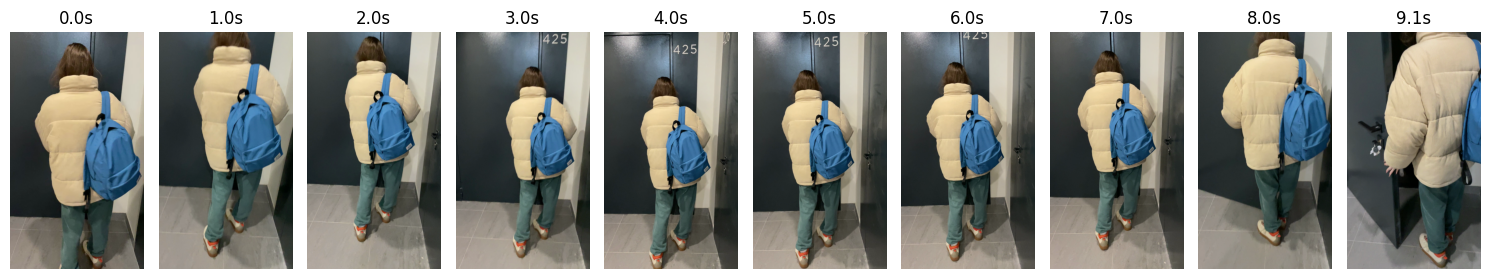

In [6]:
show_frames(frames, timestamps, max_show=10)

In [7]:
image_inputs = torch.stack([preproccess(frame) for frame in frames])

with torch.no_grad():
    image_features = model.encode_image(image_inputs)

In [8]:
image_features = image_features / image_features.norm(dim=-1, keepdim=True)

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [10]:
text_query = 'a dog'
text_tokens = clip.tokenize([text_query]).to(device)

with torch.no_grad():
    text_features = model.encode_text(text_tokens)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

In [11]:
similarity = (image_features @ text_features.T).squeeze().cpu().numpy()

In [14]:
-similarity

array([-0.23666336, -0.23505044, -0.22957546, -0.23147768, -0.21884644,
       -0.22425461, -0.23130475, -0.23837438, -0.22981375, -0.23692709,
       -0.23188785, -0.23538214, -0.2539626 , -0.24701217, -0.24754648,
       -0.23557967, -0.2598354 , -0.26480728, -0.24302223, -0.24998839,
       -0.25956398, -0.26300222, -0.27003542, -0.26451054, -0.23676424,
       -0.24880044, -0.2688541 , -0.25548303, -0.26907614, -0.24806923,
       -0.26051453, -0.2528118 , -0.26185095, -0.26711655, -0.25727463,
       -0.26671192, -0.26068753, -0.25128326, -0.25479957, -0.25296542,
       -0.24969774, -0.24743086, -0.23774762, -0.2308887 , -0.23240615,
       -0.22689396, -0.23401976, -0.25769934, -0.26609132, -0.25597036,
       -0.26095465, -0.23224878, -0.23706742, -0.25567186, -0.23237035,
       -0.24601759, -0.23627263, -0.24775346, -0.23412788, -0.23249799,
       -0.24404916, -0.21547033, -0.22874418, -0.2355876 , -0.24220046,
       -0.24086502, -0.23573685, -0.24067572, -0.27032346], dtyp

In [13]:
top_k = 5
top_indices = np.argsort(-similarity)[:top_k]

print("Top indices:", top_indices)
print("Top scores:", similarity[top_indices])
print("Top timestamps:", [timestamps[i] for i in top_indices])

Top indices: [68 22 28 26 33]
Top scores: [0.27032346 0.27003542 0.26907614 0.2688541  0.26711655]
Top timestamps: [68.41985472154964, 22.13583535108959, 28.172881355932205, 26.160532687651333, 33.20375302663438]


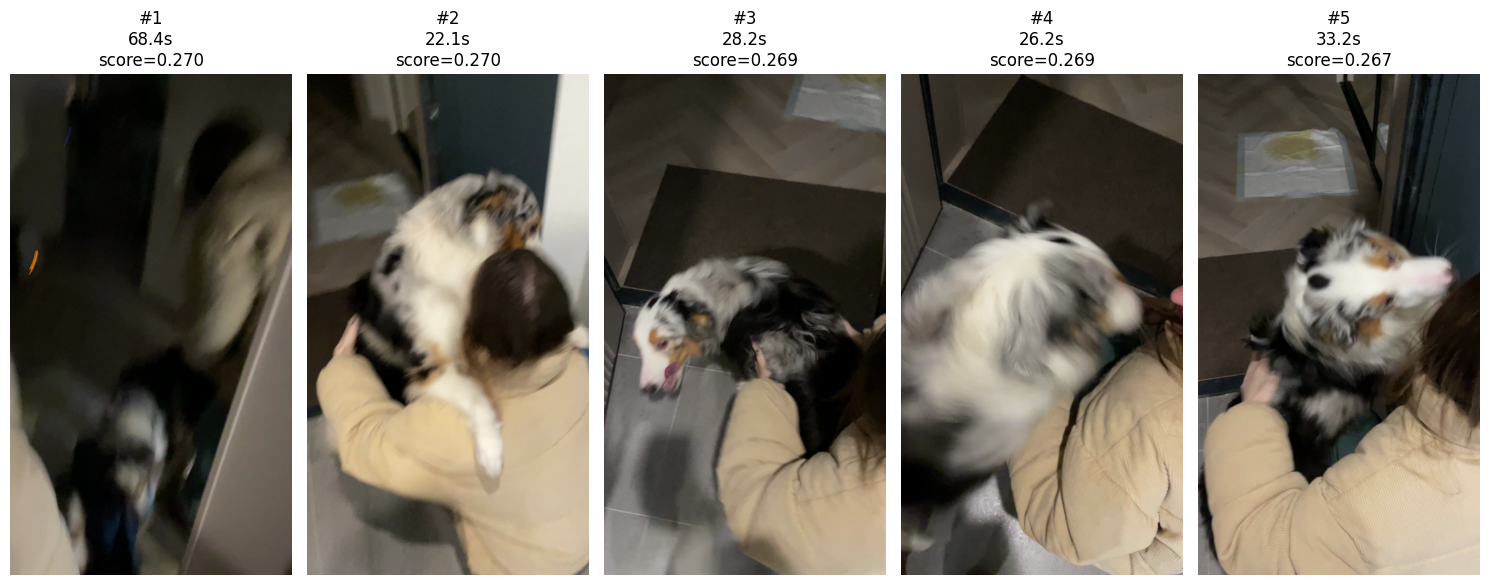

In [15]:
plt.figure(figsize=(15, 8))

for rank, idx in enumerate(top_indices, start=1):
    plt.subplot(1, top_k, rank)
    plt.imshow(frames[idx])
    plt.title(f"#{rank}\n{timestamps[idx]:.1f}s\nscore={similarity[idx]:.3f}")
    plt.axis("off")

plt.tight_layout()
plt.show()

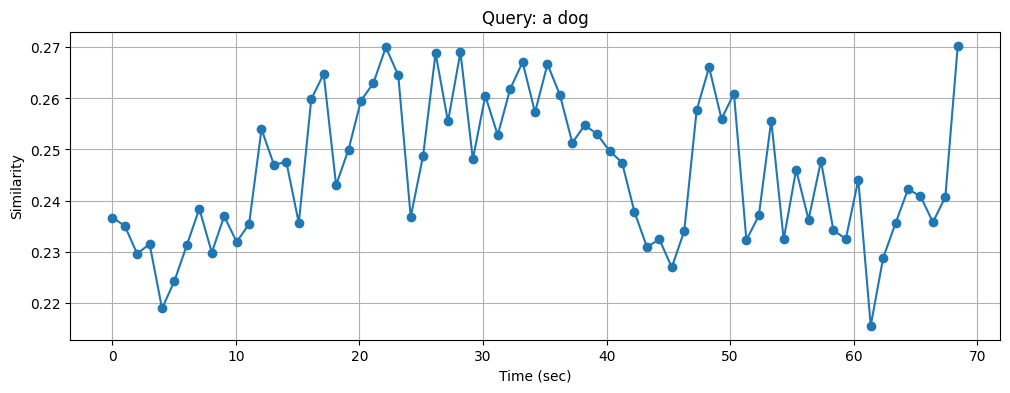

In [16]:
plt.figure(figsize=(12, 4))
plt.plot(timestamps, similarity, marker="o")
plt.xlabel("Time (sec)")
plt.ylabel("Similarity")
plt.title(f"Query: {text_query}")
plt.grid(True)
plt.show()